In [11]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("postgresql+psycopg2://devansh@localhost:5432/shipsense_db")

query = """
SELECT o.order_id, o.order_status, o.order_purchase_timestamp::timestamp AS purchase_ts,
       o.order_delivered_customer_date::timestamp AS delivered_ts,
       o.order_estimated_delivery_date::timestamp AS estimated_ts,
       c.customer_unique_id, c.customer_state,
       pay.total_payment_value AS payment_value,
       pay.primary_payment_type AS payment_type
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN (
  SELECT order_id,
         SUM(payment_value) AS total_payment_value,
         MODE() WITHIN GROUP (ORDER BY payment_type) AS primary_payment_type
  FROM order_payments
  GROUP BY order_id
) pay ON o.order_id = pay.order_id
WHERE o.order_status = 'delivered'
"""
df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(96478, 9)


,order_id,order_status,purchase_ts,delivered_ts,estimated_ts,customer_unique_id,customer_state,payment_value,payment_type
0,2711a938db643b3f0b62ee2c8a2784aa,delivered,2017-12-22 00:17:37,2018-01-09 19:52:32,2018-01-19,2ae3c67452283d5a0d30b32e0d33296e,DF,59.10,boleto
1,3bc77ce8be27211bac313c2daa402d1a,delivered,2017-04-06 22:39:29,2017-04-11 12:31:36,2017-04-27,c756e1910755edd88c00ac3f46baba4b,MG,66.98,credit_card
2,e4de6d53ecff736bc68804b0b6e9f635,delivered,2017-10-16 14:56:50,2017-11-08 21:25:24,2017-11-21,e3bcfea9bab07b492391664fc1ffc28a,BA,231.12,boleto
3,6b860b35691d486e45dc98e3514ec5f6,delivered,2017-12-08 09:42:43,2017-12-19 18:43:35,2018-01-03,4754e3b66497719a91b36268ed9c5718,SP,574.36,boleto
4,9defaf92cff22420e4e8ef7784815a55,delivered,2018-05-11 13:10:51,2018-05-21 16:09:55,2018-06-05,b11b7871c2b8be2d11fab954f58542f2,SP,62.69,credit_card


In [12]:
# Delay flag and days late
df['days_late'] = (df['delivered_ts'] - df['estimated_ts']).dt.days
df['is_late'] = (df['days_late'] > 0).astype(int)

# Order value bucket
df['order_value_bucket'] = pd.cut(df['payment_value'],
    bins=[-0.01, 50, 150, 300, float('inf')],
    labels=['low', 'medium', 'high', 'very_high'])

# Region risk score (from your Query 4 findings — merge state-level late % back in)
state_risk = df.groupby('customer_state')['is_late'].mean().rename('state_late_rate')
df = df.merge(state_risk, on='customer_state', how='left')

# Payment-type risk (does payment method correlate with delay?)
payment_risk = df.groupby('payment_type')['is_late'].mean().rename('payment_type_late_rate')
df = df.merge(payment_risk, on='payment_type', how='left')

df[['order_id', 'days_late', 'is_late', 'order_value_bucket', 'state_late_rate', 'payment_type_late_rate']].head()

,order_id,days_late,is_late,order_value_bucket,state_late_rate,payment_type_late_rate
0,2711a938db643b3f0b62ee2c8a2784aa,-10.0,0,medium,0.056731,0.073211
1,3bc77ce8be27211bac313c2daa402d1a,-16.0,0,medium,0.045711,0.066810
2,e4de6d53ecff736bc68804b0b6e9f635,-13.0,0,high,0.121622,0.073211
3,6b860b35691d486e45dc98e3514ec5f6,-15.0,0,very_high,0.044937,0.073211
4,9defaf92cff22420e4e8ef7784815a55,-15.0,0,medium,0.044937,0.066810


/var/folders/g_/tzcz3p0s0fl9dyg2xxwbw5rh0000gn/T/ipykernel_72627/525101234.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('purchase_ts').resample('M')['order_id'].count().plot(ax=axes[2])


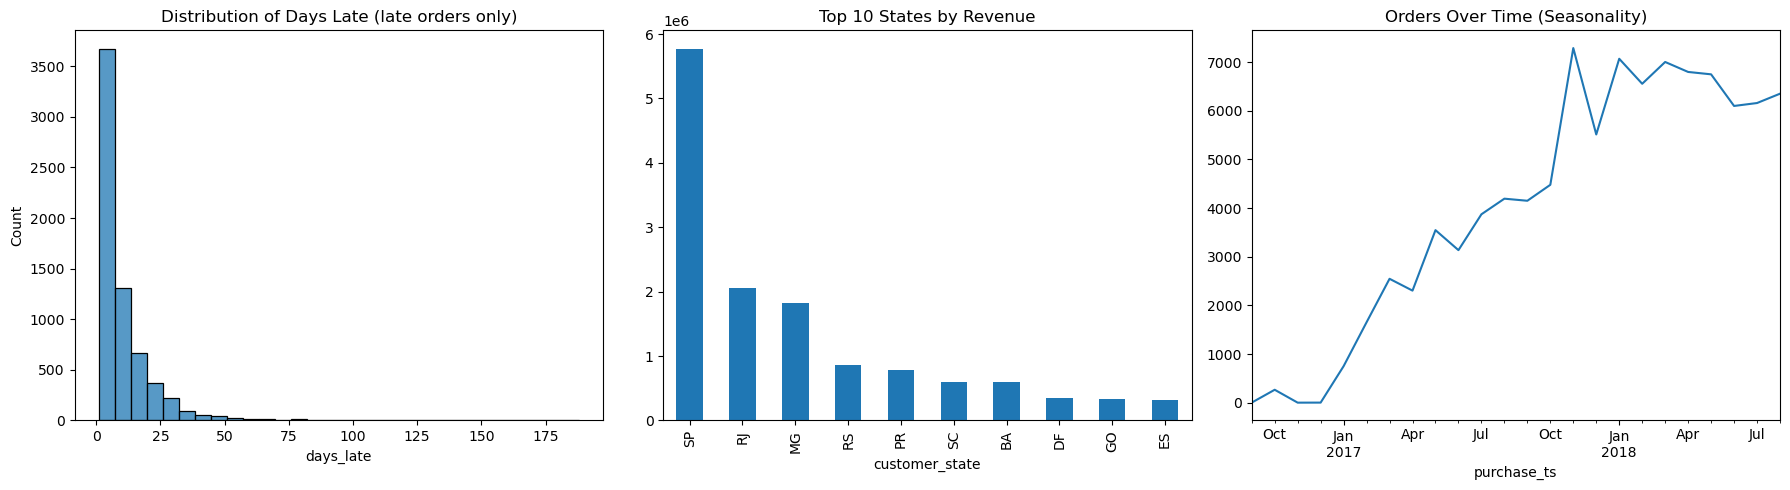

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df[df['is_late']==1]['days_late'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of Days Late (late orders only)')

df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 10 States by Revenue')

df.set_index('purchase_ts').resample('M')['order_id'].count().plot(ax=axes[2])
axes[2].set_title('Orders Over Time (Seasonality)')

plt.tight_layout()
plt.savefig('../eda_summary.png')
plt.show()

## Feature Dictionary
- **is_late**: 1 if order arrived after the estimated delivery date — our model's target variable
- **days_late**: how many days late (only meaningful when is_late=1) — used for severity analysis
- **order_value_bucket**: groups orders by spend tier — tests if expensive orders get delayed more/less
- **state_late_rate**: historical late-delivery rate for the customer's state — proxy for regional logistics risk
- **payment_type_late_rate**: historical late rate by payment method — tests if payment friction correlates with fulfillment delay

In [17]:
df.to_csv('../data_processed/shipsense_features.csv', index=False)

In [18]:
print(df.shape[0], df['order_id'].nunique())

96478 96478


In [19]:
print(df['order_value_bucket'].isnull().sum())

1


In [20]:
print("Row count:", len(df))
print("Unique orders:", df['order_id'].nunique())
print("Match:", len(df) == df['order_id'].nunique())
print("Null buckets:", df['order_value_bucket'].isnull().sum())

Row count: 96478
Unique orders: 96478
Match: True
Null buckets: 1
